<a href="https://colab.research.google.com/github/Spandana2704/DL/blob/main/WEEK10_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


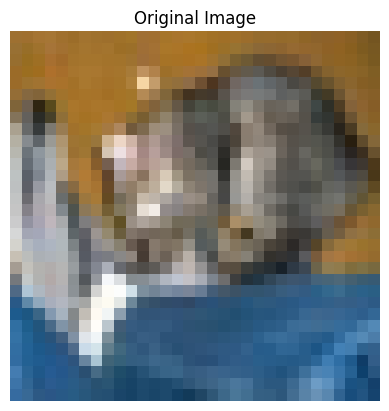

Predicted class: 3
Gradient shape: (1, 32, 32, 3)


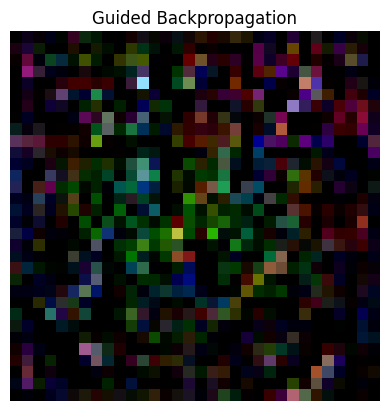

In [ ]:
img = x_test[0]
label = y_test[0][0]

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

guided_grads = tf.maximum(grads, 0)

guided_grads = guided_grads.numpy()[0]

guided_grads -= guided_grads.min()
guided_grads /= guided_grads.max()

print("Predicted class:", class_idx.numpy())
print("Gradient shape:", grads.shape)

plt.imshow(guided_grads)
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

In [ ]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

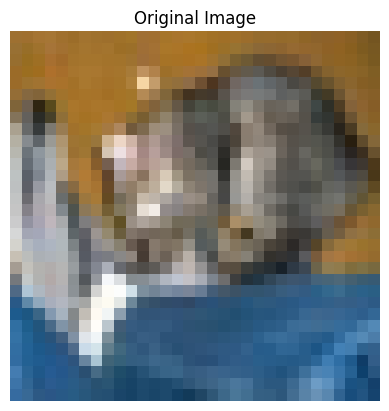

Predicted class: 3
Gradient shape: (1, 32, 32, 3)


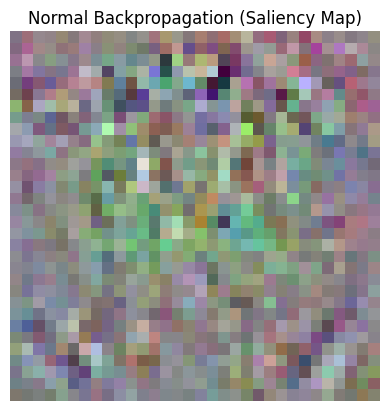

In [ ]:
img = x_test[0]
label = y_test[0][0]

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

saliency = grads.numpy()[0]

saliency -= saliency.min()
saliency /= saliency.max()

print("Predicted class:", class_idx.numpy())
print("Gradient shape:", grads.shape)

plt.imshow(saliency)
plt.title("Normal Backpropagation (Saliency Map)")
plt.axis('off')
plt.show()